### 1. Set Kernel Env

In [100]:
%load_ext autoreload
%load_ext dotenv
%dotenv
%autoreload 2

# Настраиваем окружение ноутбука: autoreload, переменные из .env, пути к src и базовые импорты.

import os
import sys
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path(os.getenv('PROJECT_ROOT_PATH'))

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import shap
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score as sk_average_precision_score,
    roc_auc_score as sk_roc_auc_score,
    brier_score_loss as sk_brier_score_loss,
    ConfusionMatrixDisplay
)

from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

import mlflow
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature

from cvm_model.parameters import (
    RANDOM_STATE,
    features,
    target,
    score,
    project_name,
    model_type,
    artifacts_dir,
    plots_dir,
    jira,
    threshold,
)

from cvm_ml_metrics.classification import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
)

import cvm_model.functions as func

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [ ]:
# Управляющие флаги запуска: можно отключить MLflow или Optuna для быстрого локального прогона.

MLFLOW_TRACKING = True

RUN_OPTUNA_TUNING = True
N_TRIALS = 30
OPTUNA_TIMEOUT = None

In [67]:
# Выбираем MLflow tracking URI: основной сервер или fallback из окружения.

if MLFLOW_TRACKING:
    MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
else:
    DEFAULT_MLFLOW_TRACKING_URI = os.getenv('DEFAULT_MLFLOW_TRACKING_URI')
    mlflow.set_tracking_uri(DEFAULT_MLFLOW_TRACKING_URI)

**Вывод по блоку:** окружение и MLflow-настройки подготовлены. Дальше все метрики, артефакты и версия модели смогут быть воспроизводимо привязаны к одному run.

### 2. State and Connections

In [4]:
# Инициализируем подключение к инфраструктуре проекта, если оно нужно для дальнейших шагов.

try:
    spark.stop()
except NameError:
    pass

    state = State.from_env()
    engine = state.credentials.loyalty_gp.sa_engine
    s3 = su.get_s3_client()

In [5]:
# Задаем месяц обучения и связанный месяц таргета/валидации.

event_timestamp = datetime(2026, 1, 1)

base_month = event_timestamp.date().replace(day=1).isoformat()
target_month = (pd.Timestamp(base_month) + pd.DateOffset(months=1)).date().isoformat()
feature_date = target_month
oot_month = target_month

base_month, target_month, feature_date, oot_month

('2026-01-01', '2026-02-01', '2026-02-01', '2026-02-01')

**Вывод по блоку:** задана временная постановка эксперимента: модель обучается на аудитории `base_month`, признаки считаются до `feature_date`, а качество дополнительно проверяется на следующем месяце через OOT.

### 3. Load Dataset

In [6]:
# Загружаем полный train-датасет за base_month и проверяем базовые инварианты.

dataset_path = Path(f'df_{base_month}.parquet')

df = pd.read_parquet(dataset_path)

print('df:', df.shape)
print('target rate:', df[target].mean())

assert target in df.columns
assert df['contact_id'].nunique() == len(df)

df: (996200, 162)
target rate: 0.1609445894398715


**Вывод по блоку:** загружен полный train-датасет без отдельного train/test split. Качество будет оцениваться через OOF-предсказания, как в оригинальной модели.

### 4. Optuna Tuning

In [7]:
# При включенном флаге подбираем гиперпараметры CatBoost через Optuna по PR-AUC.

if RUN_OPTUNA_TUNING:
    import optuna

    X_train_tune, X_val_tune, y_train_tune, y_val_tune, z_train_tune, _ = train_test_split(
        df[features],
        df[target],
        df['strat'],
        stratify=df['strat'],
        test_size=0.25,
        random_state=RANDOM_STATE,
    )

    def objective(trial):
        params_trial = {
            'random_state': RANDOM_STATE,
            'loss_function': 'Logloss',
            'eval_metric': 'PRAUC',
            'iterations': trial.suggest_int('iterations', 300, 1200),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
            'border_count': trial.suggest_categorical('border_count', [64, 128, 254]),
            'early_stopping_rounds': 50,
            'thread_count': -1,
            'verbose': False,
        }

        bootstrap_type = trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS'])
        params_trial['bootstrap_type'] = bootstrap_type

        if bootstrap_type == 'Bayesian':
            params_trial['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 5.0)
        else:
            params_trial['subsample'] = trial.suggest_float('subsample', 0.6, 1.0)

        tune_model = CatBoostClassifier(**params_trial)
        tune_model.fit(
            X_train_tune,
            y_train_tune,
            eval_set=(X_val_tune, y_val_tune),
            use_best_model=True,
            verbose=False,
        )

        val_pred = tune_model.predict_proba(X_val_tune)[:, 1]
        return sk_average_precision_score(y_val_tune, val_pred)

    study = optuna.create_study(
        direction='maximize',
        study_name=f'mvp_catboost_{base_month}_churn_from_dac_pr_auc',
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT, show_progress_bar=True)

    print('Best Optuna validation PR-AUC:', study.best_value)
    print('Best params:')
    display(study.best_params)

    CATBOOST_PARAMS = {
        'random_state': RANDOM_STATE,
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'early_stopping_rounds': 50,
        'thread_count': -1,
        'verbose': False,
        **study.best_params,
    }
else:
    print('Optuna tuning skipped.')

Optuna tuning skipped.


In [8]:
# Фиксируем параметры CatBoost для воспроизводимого MVP-запуска.

CATBOOST_PARAMS = {
    'random_state': RANDOM_STATE,
    'loss_function': 'Logloss',
    'eval_metric': 'PRAUC',
    'iterations': 1106,
    'learning_rate': 0.04092870749826398,
    'depth': 8,
    'l2_leaf_reg': 8.696367472979667,
    'random_strength': 1.5293146536315834,
    'border_count': 64,
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.6999263676247318,
    'early_stopping_rounds': 50,
    'thread_count': -1,
    'verbose': False,
}

**Вывод по блоку:** параметры CatBoost зафиксированы для MVP. Если `RUN_OPTUNA_TUNING=True`, параметры могут быть обновлены Optuna; если флаг выключен, используется стабильная заранее выбранная конфигурация.

### 5. StratifiedKFold Cross-Validation (OOF)

In [ ]:
# Создаем стратифицированный разбиение на 5 фолдов для OOF-оценки.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
# Обучаем модель на каждом фолде и сохраняем OOF-предсказания для честной оценки качества.

X = df[features]
y = df[target]
z = df['strat']

cv_predicts = np.zeros(len(df))
cv_ap_gain = []
cv_pr_auc = []
cv_roc_auc = []

for i, (train_idx, val_idx) in enumerate(skf.split(X, z), start=1):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    print()
    print(f'Training fold {i}...')
    fold_model = CatBoostClassifier(**CATBOOST_PARAMS)
    fold_model.fit(X_train, y_train, plot=False, verbose=0)

    print(f'Scoring fold {i}...')
    cv_predicts[val_idx] = fold_model.predict_proba(X_val)[:, 1]

    fold_pr_auc = sk_average_precision_score(y_val, cv_predicts[val_idx])
    fold_roc_auc = sk_roc_auc_score(y_val, cv_predicts[val_idx])
    fold_ap_gain = fold_pr_auc - y_val.mean()

    cv_pr_auc.append(fold_pr_auc)
    cv_roc_auc.append(fold_roc_auc)
    cv_ap_gain.append(fold_ap_gain)

    print(f'Fold {i} PR-AUC = {fold_pr_auc:.6f}; ROC-AUC = {fold_roc_auc:.6f}; AP gain = {fold_ap_gain:.6f}')

    df[score] = cv_predicts

In [ ]:
# Агрегируем метрики CV по фолдам: среднее качество и разброс между фолдами.

cv_metrics = {
        'fold_pr_auc_mean': float(np.mean(cv_pr_auc)),
        'fold_pr_auc_std': float(np.std(cv_pr_auc)),
        'fold_roc_auc_mean': float(np.mean(cv_roc_auc)),
        'fold_roc_auc_std': float(np.std(cv_roc_auc)),
        'fold_ap_gain_mean': float(np.mean(cv_ap_gain)),
        'fold_ap_gain_std': float(np.std(cv_ap_gain)),
    }

display(pd.DataFrame(cv_metrics, index=['value']).T)

**Вывод по блоку:** OOF/CV дает честную внутреннюю оценку качества: каждый клиент скорится моделью, которая не видела его в своем фолде. Разброс метрик по фолдам показывает устойчивость модели.

### 6. Train Model On Full Dataset

In [10]:
# После CV обучаем финальную модель на всем доступном train-датасете.

model = CatBoostClassifier(**CATBOOST_PARAMS)

model.fit(df[features], df[target], plot=False, verbose=100)

0:	learn: 0.4950451	total: 114ms	remaining: 2m 5s
100:	learn: 0.5478330	total: 18.8s	remaining: 3m 7s
200:	learn: 0.5547891	total: 37.9s	remaining: 2m 50s
300:	learn: 0.5597535	total: 57.1s	remaining: 2m 32s
400:	learn: 0.5655970	total: 1m 16s	remaining: 2m 14s
500:	learn: 0.5716461	total: 1m 35s	remaining: 1m 55s
600:	learn: 0.5770718	total: 1m 58s	remaining: 1m 39s
700:	learn: 0.5822266	total: 2m 17s	remaining: 1m 19s
800:	learn: 0.5869090	total: 2m 36s	remaining: 59.5s
900:	learn: 0.5915195	total: 2m 54s	remaining: 39.8s
1000:	learn: 0.5961401	total: 3m 13s	remaining: 20.3s
1100:	learn: 0.6006243	total: 3m 32s	remaining: 965ms
1105:	learn: 0.6008565	total: 3m 33s	remaining: 0us


CatBoostClassifier(bootstrap_type='Bernoulli', border_count=64, depth=8, early_stopping_rounds=50, eval_metric='PRAUC', iterations=1106, l2_leaf_reg=8.696367472979667, learning_rate=0.04092870749826398, loss_function='Logloss', random_state=42, random_strength=1.5293146536315834, subsample=0.6999263676247318, verbose=False)

**Вывод по блоку:** финальная модель обучена на всем train-датасете. Именно эта версия далее используется для OOT-валидации, логирования в MLflow и будущего инференса.

### 7. Threshold Tuning

In [40]:
# Подбираем threshold по F-beta на OOF-скорах и сравниваем сценарии precision/recall.

def find_threshold(y_true, y_pred, eval_function, **kwargs):
    score_by_threshold = {}

    for threshold_value in np.arange(0.05, 1, 0.05):
        y_class = y_pred > threshold_value
        score_by_threshold[threshold_value] = eval_function(y_true, y_class, **kwargs)

    return max(score_by_threshold.items(), key=lambda x: x[1])[0]


t = df[target]
s = df[score]

threshold_rows = []

for beta in [0.35, 0.5, 1, 2]:
    threshold_value = find_threshold(t, s, fbeta_score, beta=beta)
    y_class = s > threshold_value

    threshold_rows.append({
        'beta': beta,
        'threshold': threshold_value,
        'selected_share': y_class.mean(),
        'precision': precision_score(t, y_class),
        'recall': recall_score(t, y_class),
        'f1': f1_score(t, y_class),
        'fbeta': fbeta_score(t, y_class, beta=beta),
    })

threshold_report = pd.DataFrame(threshold_rows)
display(threshold_report)

,beta,threshold,selected_share,precision,recall,f1,fbeta
0,0.35,0.50,0.09,0.62,0.34,0.44,0.57
1,0.50,0.45,0.11,0.59,0.41,0.49,0.55
2,1.00,0.25,0.25,0.45,0.72,0.56,0.56
3,2.00,0.15,0.37,0.38,0.85,0.52,0.68


По результатам подбора `threshold` на OOF-скорах оптимальный порог по F1 составляет 0.25.

**Вывод по блоку:** threshold выбирается по OOF-скорам. Порог по F1 можно использовать как базовый MVP-вариант, а F0.5/F2 показывают более консервативный или recall-oriented сценарий.

### 8. OOF Evaluation

In [46]:
# Считаем основные OOF-метрики при выбранном threshold.

metrics = func.calculate_binary_metrics(df[target], df[score], threshold)

display(pd.DataFrame(metrics, index=['value']).T)

,value
roc_auc,0.87
pr_auc,0.55
ap_gain,0.39
threshold,0.25
predicted_positive_share,0.25
precision,0.45
recall,0.72
f1,0.56
f05,0.49
f2,0.64


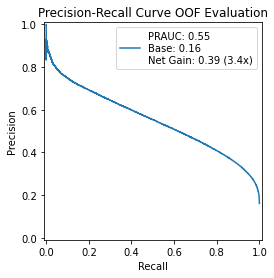

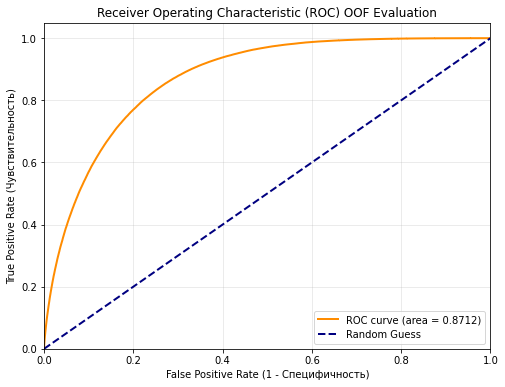

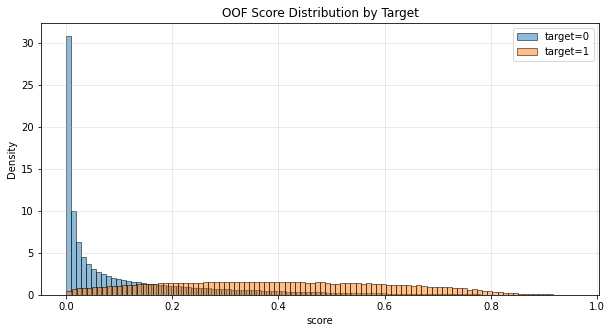

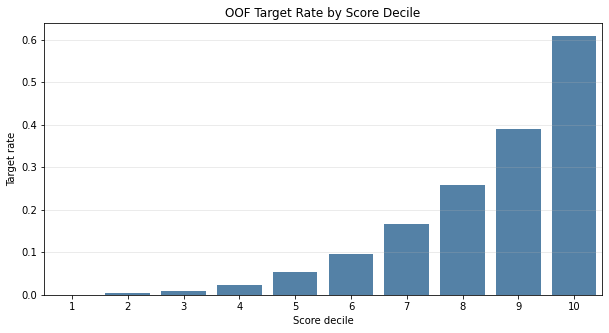

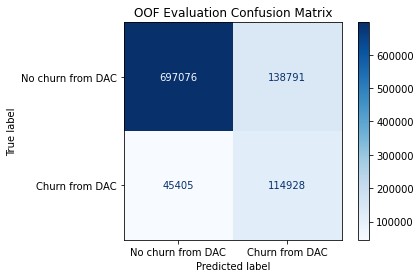

In [101]:
# Строим основные OOF-графики: PR/ROC, распределение score, децили и confusion matrix.

func.plot_precision_recall_curve(df[target], df[score], title_suffix='OOF Evaluation', artifacts_dir=plots_dir)

func.plot_roc(df[target], df[score], title_suffix='OOF Evaluation', artifacts_dir=plots_dir)

func.plot_score_distribution(df, score, target, 'OOF Score Distribution by Target', artifacts_dir=plots_dir)

deciles = func.decile_report(df, score, target)

func.plot_target_rate_by_decile(deciles, "OOF Target Rate by Score Decile", artifacts_dir=plots_dir)

ConfusionMatrixDisplay.from_predictions(
    df[target],
    df[score] > threshold,
    display_labels=['No churn from DAC', 'Churn from DAC'],
    cmap='Blues',
    values_format='d',
)

plt.title('OOF Evaluation Confusion Matrix')
plt.show()

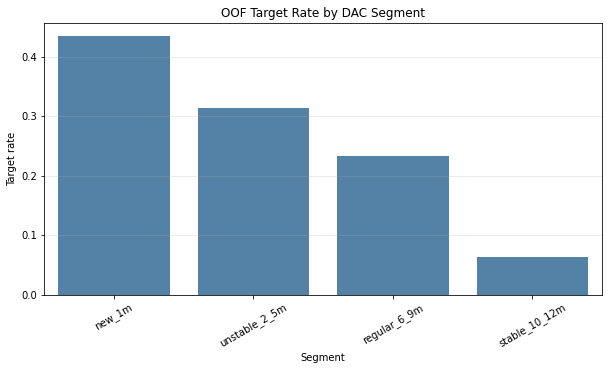

In [102]:
# Проверяем качество и target rate в разрезе DAC-сегментов.

segment_rows = []

for segment_name, part in df.groupby('segment'):
    if part[target].nunique() < 2:
        continue
    segment_rows.append({
        'segment': segment_name,
        'rows': len(part),
        'target_rate': float(part[target].mean()),
        'pr_auc': float(sk_average_precision_score(part[target], part[score])),
        'roc_auc': float(sk_roc_auc_score(part[target], part[score])),
    })

segment_metrics = pd.DataFrame(segment_rows).sort_values('pr_auc', ascending=False)

func.plot_segment_target_rate(segment_metrics, 'OOF Target Rate by DAC Segment', artifacts_dir=plots_dir)

plt.show()

**Вывод по блоку:** OOF-графики и сегментный отчет показывают, насколько модель разделяет клиентов по риску и сохраняется ли качество внутри DAC-сегментов.

### 9. Calibration: Platt / Spline / Isotonic

In [63]:
# Проверяем дополнительные калибраторы поверх raw CatBoost score через CV.

platt = LogisticRegression(C=1e10)
platt_spline = make_pipeline(
    SplineTransformer(n_knots=5, degree=3),
    LogisticRegression(C=1.0),
)
isotonic = IsotonicRegression(out_of_bounds='clip')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X = pd.DataFrame(df[score])
y = df[target]
z = df['strat']

X_scored = pd.DataFrame()

for i, (train_idx, val_idx) in enumerate(skf.split(X, z), start=1):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val = X.iloc[val_idx].copy()
    X_val_copy = X_val.copy()

    print(f'Calibrating on fold {i}...')

    platt.fit(X_train, y_train)
    platt_spline.fit(X_train, y_train)
    isotonic.fit(X_train, y_train)

    X_val[f'{score}_platt'] = platt.predict_proba(X_val_copy)[:, 1]
    X_val[f'{score}_platt_spline'] = platt_spline.predict_proba(X_val_copy)[:, 1]
    X_val[f'{score}_isotonic'] = isotonic.transform(X_val_copy)

    X_scored = pd.concat([X_scored, X_val], axis=0)

calibrated_cols = [f'{score}_platt', f'{score}_platt_spline', f'{score}_isotonic']
df[calibrated_cols] = X_scored.sort_index()[calibrated_cols]

display(df[[score] + calibrated_cols].head())

Calibrating on fold 1...
Calibrating on fold 2...
Calibrating on fold 3...
Calibrating on fold 4...
Calibrating on fold 5...


,score,score_platt,score_platt_spline,score_isotonic
0,0.26,0.19,0.26,0.27
1,0.35,0.28,0.34,0.35
2,0.41,0.38,0.41,0.41
3,0.42,0.40,0.43,0.42
4,0.04,0.05,0.03,0.04


In [64]:
# Сравниваем raw и calibrated scores по ранжирующим и вероятностным метрикам.

calibration_metrics = []

for score_col in [
    score,
    f'{score}_platt',
    f'{score}_platt_spline',
    f'{score}_isotonic',
]:
    calibration_metrics.append({
        'score': score_col,
        'roc_auc': sk_roc_auc_score(df[target], df[score_col]),
        'pr_auc': sk_average_precision_score(df[target], df[score_col]),
        'ap_gain': sk_average_precision_score(df[target], df[score_col]) - df[target].mean(),
        'brier': sk_brier_score_loss(df[target], df[score_col]),
    })

calibration_metrics = pd.DataFrame(calibration_metrics).sort_values('brier')
display(calibration_metrics)

,score,roc_auc,pr_auc,ap_gain,brier
0,score,0.87,0.55,0.39,0.10
3,score_isotonic,0.87,0.55,0.39,0.10
2,score_platt_spline,0.87,0.55,0.39,0.10
1,score_platt,0.87,0.55,0.39,0.10


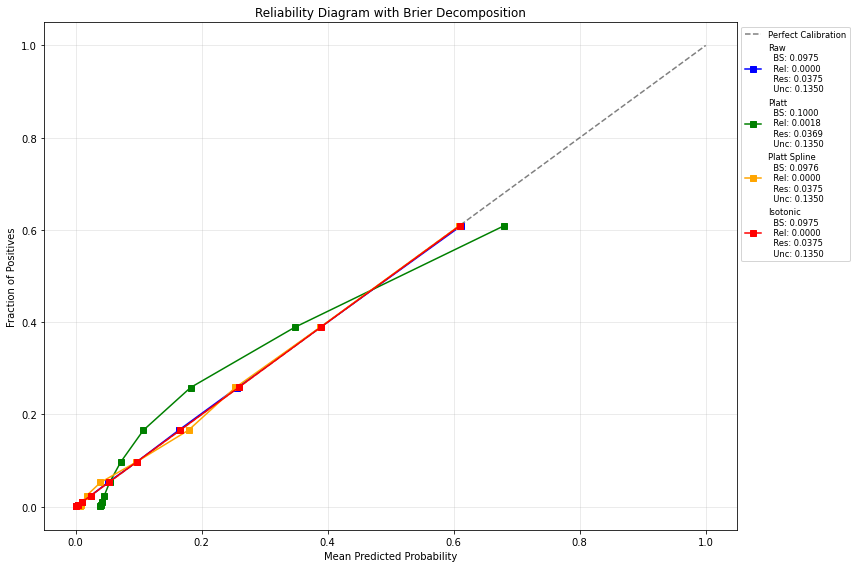

In [65]:
# Визуально проверяем калибровку через reliability diagram и Brier decomposition.

plt.figure(figsize=(12, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', alpha=0.5)

models = [
    (df[score], 'Raw', 'blue'),
    (df[f'{score}_platt'], 'Platt', 'green'),
    (df[f'{score}_platt_spline'], 'Platt Spline', 'orange'),
    (df[f'{score}_isotonic'], 'Isotonic', 'red'),
]

for pred, name, color in models:
    rel, res, unc = func.brier_decomposition(df[target], pred)
    bs = rel - res + unc

    f_pos, m_val = calibration_curve(
        df[target],
        pred,
        n_bins=10,
        strategy='quantile',
    )

    label = (
        f'{name}\n'
        f'  BS: {bs:.4f}\n'
        f'  Rel: {rel:.4f}\n'
        f'  Res: {res:.4f}\n'
        f'  Unc: {unc:.4f}'
    )

    plt.plot(m_val, f_pos, 's-', color=color, label=label)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Reliability Diagram with Brier Decomposition')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод по блоку:** калибровка используется как диагностика вероятностной интерпретации score. Если raw score ближе к диагонали и имеет лучший Brier/reliability, дополнительный калибратор в MVP не нужен.

### 10. Evaluation On Next Month (OOT)

In [ ]:
# Загружаем OOT-датасет следующего месяца для внешней проверки модели.

oot_dataset_path = Path(f'df_{oot_month}.parquet')
oot_df = func.prepare_dataset(pd.read_parquet(oot_dataset_path), target)

assert target in oot_df.columns
oot_score = 'oot_score'

In [49]:
# Скорим OOT-датасет финальной моделью, обученной на полном train.

oot_df[oot_score] = model.predict_proba(oot_df[features])[:, 1]

In [30]:
# Считаем OOT-метрики, чтобы проверить переносимость модели на следующий месяц.

oot_metrics = func.calculate_binary_metrics(oot_df[target], oot_df[oot_score], threshold)

display(pd.DataFrame(oot_metrics, index=['oot']).T)

,oot
roc_auc,0.87
pr_auc,0.49
ap_gain,0.36
threshold,0.30
predicted_positive_share,0.20
precision,0.42
recall,0.66
f1,0.51
f05,0.45
f2,0.59


**Вывод по блоку:** OOT-валидация показывает, переносится ли модель на следующий месяц. Для бизнес-решения этот блок важнее train-метрик, потому что имитирует реальный инференс.

### 11. Feature Importance and SHAP Values

In [50]:
# Получаем встроенные feature importance из CatBoost.

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.get_feature_importance(),
}).sort_values('importance', ascending=False)

display(feature_importance.head(15))

,feature,importance
34,login_recency,11.26
39,cheque_recency,8.87
48,omni_qr_recency,4.76
2,dac_months_last_12,3.63
23,login_lag_avg_2,3.40
0,dac_months_last_6,2.93
5,trans_lag_avg_3,2.76
8,login_lag_avg_3,2.71
15,login_count_1,2.68
1,is_stable_dac,2.61


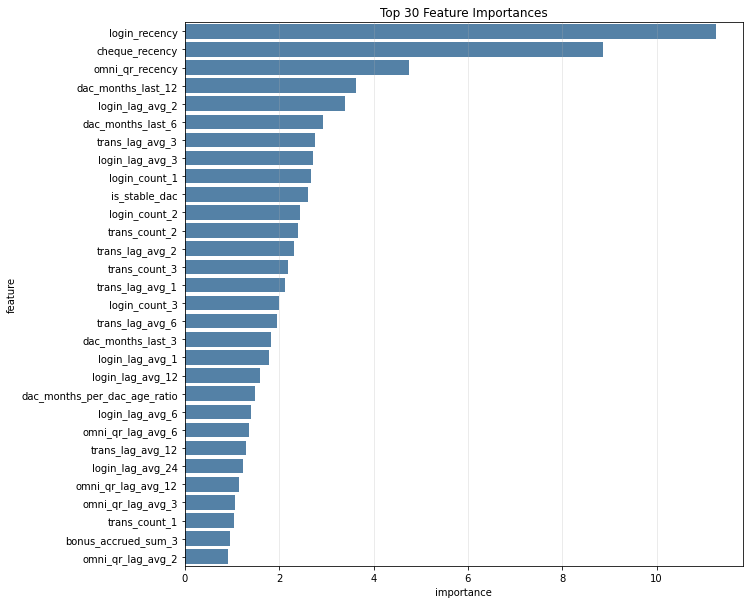

In [36]:
# Визуализируем top-30 наиболее важных признаков.

plt.figure(figsize=(10, 10))
sns.barplot(data=feature_importance.head(30), x='importance', y='feature', color='steelblue')
plt.title('Top 30 Feature Importances')
plt.grid(axis='x', alpha=0.3)
plt.show()

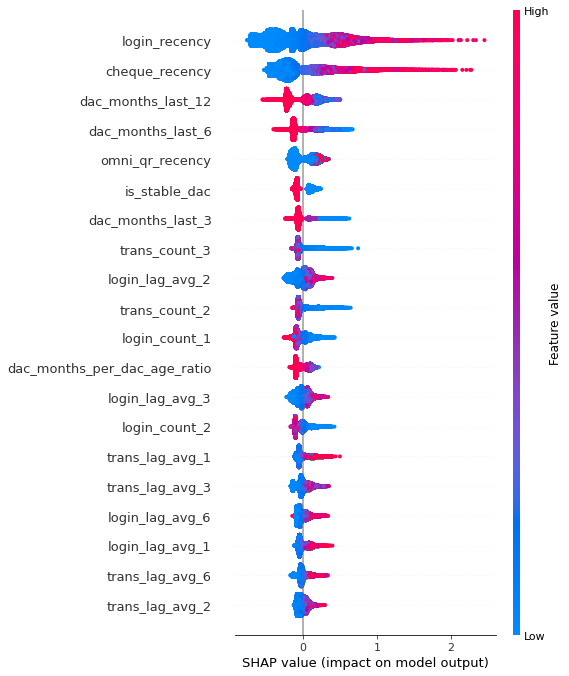

In [37]:
# Считаем SHAP на сэмпле, чтобы интерпретировать влияние фичей на прогноз.

shap_val_sample_size = min(200_000, len(X_val))
X_val_sample = X_val.sample(shap_val_sample_size, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(model)
shap_vals_val = explainer.shap_values(X_val_sample)
shap.summary_plot(shap_vals_val, X_val_sample)

**Вывод по блоку:** feature importance и SHAP помогают объяснить, за счет каких признаков модель принимает решения, и проверить, что качество не держится на подозрительных или служебных колонках.

### 12. Save Model And Log To MLflow

In [ ]:
# Готовим папки для артефактов и графиков перед сохранением результатов.

artifacts_path = Path(artifacts_dir)
artifacts_path.mkdir(parents=True, exist_ok=True)

plots_path = Path(plots_dir)
plots_path.mkdir(parents=True, exist_ok=True)

In [ ]:
# Сохраняем локальные артефакты: список фичей, importance, отчеты и модель CatBoost.

features_file = artifacts_path / 'features.txt'
feature_importance_file = artifacts_path / 'feature_importance.csv'
deciles_file = artifacts_path / 'oof_deciles.csv'
segments_file = artifacts_path / 'oof_segment_metrics.csv'
model_file = artifacts_path / 'final_mvp_model_churn_from_dac.cbm'

features_file.write_text('\n'.join(features), encoding='utf-8')
feature_importance.to_csv(feature_importance_file, index=False)
deciles.to_csv(deciles_file)
segment_metrics.to_csv(segments_file, index=False)
model.save_model(str(model_file))

In [ ]:
# Логируем параметры, метрики, артефакты и финальную модель в MLflow Model Registry.

if MLFLOW_TRACKING:

    model_name = f'{project_name}_{model_type}'
    experiment_name = f'{project_name}_{model_type}_{jira}_train'
    mlflow.set_experiment(experiment_name)

    signature = infer_signature(df.head(1)[features], df.head(1)[score])

    description = f'train_{base_month}'

    with mlflow.start_run(run_name=description, description='description'):
        mlflow.log_param('base_month', base_month)
        mlflow.log_param('target_month', target_month)
        mlflow.log_param('feature_set', features)
        mlflow.log_param('features_count', len(features))
        mlflow.log_param('threshold', threshold)
        mlflow.log_param('target_rate', float(df[target].mean()))

        for k, v in CATBOOST_PARAMS.items():
            if isinstance(v, (str, int, float, bool)) or v is None:
                mlflow.log_param(f'catboost_{k}', v)

        for k, v in metrics.items():
            mlflow.log_metric(k, float(v))

        for k, v in cv_metrics.items():
            mlflow.log_metric(f'cv_{k}', float(v))

        for _, row in segment_metrics.iterrows():
            seg = str(row['segment']).replace('-', '_').replace(' ', '_')
            mlflow.log_metric(f'segment_{seg}_pr_auc', float(row['pr_auc']))
            mlflow.log_metric(f'segment_{seg}_roc_auc', float(row['roc_auc']))

        for path in [features_file, feature_importance_file, deciles_file, segments_file, model_file]:
            mlflow.log_artifact(str(path))

        mlflow.log_artifacts(str(plots_dir), artifact_path='plots')

        mlflow.sklearn.log_model(
            model,
            name=model_name,
            signature=signature,
            registered_model_name=model_name,
            )

        print('Logged to MLflow experiment:', experiment_name)
        print('Registered model:', model_name)

**Вывод по блоку:** модель, метрики, параметры и артефакты сохранены в MLflow. Это позволяет сравнивать запуски и затем загрузить зарегистрированную модель для инференса.

### 13. Save Scored Outputs

In [ ]:
# Сохраняем OOF-скоры клиентов в parquet для последующего анализа или сверки.

score_result = df[['contact_id', score]].copy()
score_result = score_result.rename(columns={score: 'score_churn_from_dac'})
score_result['score_month'] = target_month
if 'segment' in df.columns:
    score_result['dac_segment'] = df['segment'].values

score_result_path = Path(f'scores_{base_month}.parquet')
score_result.to_parquet(score_result_path, index=False)

print('Saved:', score_result_path.resolve())
display(score_result.head())

**Вывод по блоку:** OOF-скоры сохранены отдельно. Их можно использовать для проверки децилий, сегментного анализа и подготовки финального отчета по MVP.